# Digital Payment Analytics — Data Cleaning & EDA

This notebook mirrors the Power Query cleaning steps and Power BI KPI logic used in `dashboard/Digital_Payment_Analytics.pbix`, and adds exploratory analysis to support the findings in `README.md`.

**Phases covered:**
1. Load & inspect data
2. Clean data (types, duplicates, missing values)
3. Add derived columns
4. Exploratory data analysis (KPIs, charts)
5. Customer segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load & Inspect Data

In [2]:
df = pd.read_csv(r'C:\Users\nilaa\OneDrive\Desktop\Digital Payment Analytics\data\upi_transactions_2024.csv')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Rows: 250,000  |  Columns: 17


,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   transaction id      250000 non-null  str  
 1   timestamp           250000 non-null  str  
 2   transaction type    250000 non-null  str  
 3   merchant_category   250000 non-null  str  
 4   amount (INR)        250000 non-null  int64
 5   transaction_status  250000 non-null  str  
 6   sender_age_group    250000 non-null  str  
 7   receiver_age_group  250000 non-null  str  
 8   sender_state        250000 non-null  str  
 9   sender_bank         250000 non-null  str  
 10  receiver_bank       250000 non-null  str  
 11  device_type         250000 non-null  str  
 12  network_type        250000 non-null  str  
 13  fraud_flag          250000 non-null  int64
 14  hour_of_day         250000 non-null  int64
 15  day_of_week         250000 non-null  str  
 16  is_weekend          250000 non-

In [4]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False)

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

## 2. Clean Data

In [6]:
# ==========================================
# DATA CLEANING - UPI TRANSACTIONS DATASET
# ==========================================

import pandas as pd

# Load dataset
df = pd.read_csv(r'C:\Users\nilaa\OneDrive\Desktop\Digital Payment Analytics\data\upi_transactions_2024.csv')


print("Original Shape:", df.shape)

# ------------------------------------------
# 1. Remove duplicate rows
# ------------------------------------------
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

# ------------------------------------------
# 2. Remove leading/trailing spaces
# ------------------------------------------
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# ------------------------------------------
# 3. Convert data types
# ------------------------------------------

# Timestamp
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Amount
if 'amount (INR)' in df.columns:
    df['amount (INR)'] = pd.to_numeric(df['amount (INR)'], errors='coerce')

# ------------------------------------------
# 4. Handle missing values
# ------------------------------------------

# Numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Text columns
text_cols = df.select_dtypes(include=['object', 'string']).columns

for col in text_cols:
    df[col] = df[col].fillna("Unknown")

# ------------------------------------------
# 5. Remove invalid amount values
# ------------------------------------------

if 'amount (INR)' in df.columns:
    df = df[df['amount (INR)'] >= 0]

# ------------------------------------------
# 6. Reset index
# ------------------------------------------

df.reset_index(drop=True, inplace=True)

# ------------------------------------------
# 7. Check missing values
# ------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCleaned Shape:", df.shape)

# ------------------------------------------
# 8. Save cleaned dataset
# ------------------------------------------

df.to_csv("upi_transactions_cleaned.csv", index=False)

print("\nData cleaning completed successfully!")
print("Cleaned file saved as 'upi_transactions_cleaned.csv'")

Original Shape: (250000, 17)
Removed 0 duplicate rows


C:\Users\nilaa\AppData\Local\Temp\ipykernel_20000\1987455988.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:



Missing Values:
transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

Cleaned Shape: (250000, 17)

Data cleaning completed successfully!
Cleaned file saved as 'upi_transactions_cleaned.csv'


In [7]:
before = len(df)

if 'transaction_id' in df.columns:
    df = df.drop_duplicates(subset='transaction_id', keep='first')
    print(f"Removed {before - len(df)} duplicate rows")
else:
    print("'transaction_id' column not found.")
    print("Available columns:")
    print(df.columns.tolist())

'transaction_id' column not found.
Available columns:
['transaction id', 'timestamp', 'transaction type', 'merchant_category', 'amount (INR)', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'fraud_flag', 'hour_of_day', 'day_of_week', 'is_weekend']


In [10]:
# ==========================================
# HANDLE MISSING VALUES
# ==========================================

# Critical columns (only keep those that exist)
critical_cols = [
    'transaction_status',
    'amount (INR)',
    'timestamp',
    'transaction_id'
]

existing_cols = [col for col in critical_cols if col in df.columns]

before = len(df)

if existing_cols:
    df = df.dropna(subset=existing_cols)
    print(f"Dropped {before - len(df)} rows with missing critical fields")
else:
    print("No matching critical columns found.")

# Fill missing values in categorical columns
fill_unknown = [
    'sender_bank',
    'receiver_bank',
    'sender_state'
]

for col in fill_unknown:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Fill missing fraud_flag with 0
if 'fraud_flag' in df.columns:
    df['fraud_flag'] = df['fraud_flag'].fillna(0)

print("Missing value handling completed successfully.")

Dropped 0 rows with missing critical fields
Missing value handling completed successfully.


## 3. Derived Columns

In [11]:
# Peak Hour Flag
df['Peak Hour Flag'] = np.where(
    ((df['hour_of_day'] >= 9) & (df['hour_of_day'] <= 12)) |
    ((df['hour_of_day'] >= 18) & (df['hour_of_day'] <= 21)),
    'Peak', 'Off-Peak'
)

# High-Value Transaction Flag
df['High-Value Transaction Flag'] = np.where(df['amount (INR)'] > 5000, 'High Value', 'Regular')

df[['hour_of_day', 'Peak Hour Flag', 'amount (INR)', 'High-Value Transaction Flag']].head()

,hour_of_day,Peak Hour Flag,amount (INR),High-Value Transaction Flag
0,15,Off-Peak,868,Regular
1,6,Off-Peak,1011,Regular
2,13,Off-Peak,477,Regular
3,10,Peak,2784,Regular
4,19,Peak,990,Regular


## 4. KPI Calculations
These mirror the DAX measures built in Power BI.

In [12]:
total_transactions = len(df)
total_volume = df['amount (INR)'].sum()
success_count = (df['transaction_status'] == 'SUCCESS').sum()
failed_count = (df['transaction_status'] == 'FAILED').sum()
success_rate = success_count / total_transactions
failure_rate = failed_count / total_transactions
avg_txn_value = df['amount (INR)'].mean()

print(f'Total Transactions:      {total_transactions:,}')
print(f'Total Payment Volume:    Rs {total_volume:,.0f}')
print(f'Success Rate:            {success_rate:.2%}')
print(f'Failure Rate:            {failure_rate:.2%}')
print(f'Average Transaction Value: Rs {avg_txn_value:,.2f}')

Total Transactions:      250,000
Total Payment Volume:    Rs 327,939,009
Success Rate:            95.05%
Failure Rate:            4.95%
Average Transaction Value: Rs 1,311.76


## 5. Analytics Investigation

In [14]:
import matplotlib.pyplot as plt

# Check if required columns exist
if 'transaction_type' in df.columns and 'amount (INR)' in df.columns:

    volume_by_type = (
        df.groupby('transaction_type')['amount (INR)']
        .sum()
        .sort_values(ascending=False)
    )

    volume_by_type.plot(
        kind='bar',
        figsize=(8, 4),
        title='Total Payment Volume by Transaction Type'
    )

    plt.xlabel("Transaction Type")
    plt.ylabel("Total Volume (INR)")
    plt.tight_layout()
    plt.show()

else:
    print("Required columns not found.")
    print("Available columns are:")
    print(df.columns.tolist())

Required columns not found.
Available columns are:
['transaction id', 'timestamp', 'transaction type', 'merchant_category', 'amount (INR)', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'fraud_flag', 'hour_of_day', 'day_of_week', 'is_weekend', 'Peak Hour Flag', 'High-Value Transaction Flag']


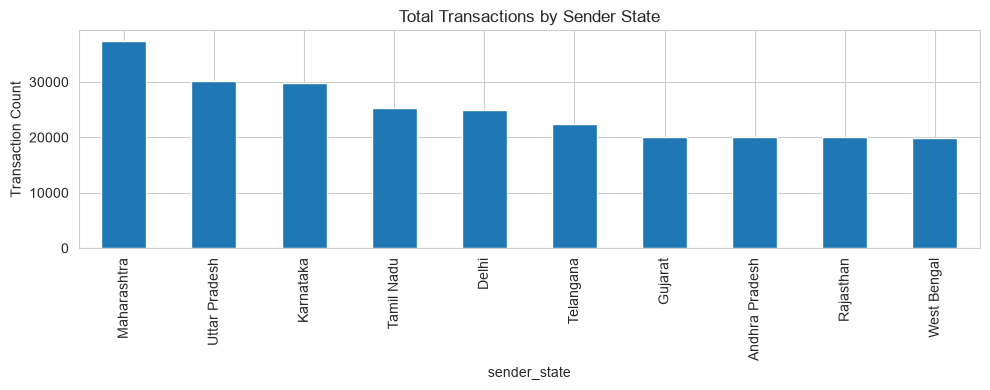

In [15]:
# State vs Transaction Count
count_by_state = df['sender_state'].value_counts().sort_values(ascending=False)
count_by_state.plot(kind='bar', figsize=(10, 4), title='Total Transactions by Sender State')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()

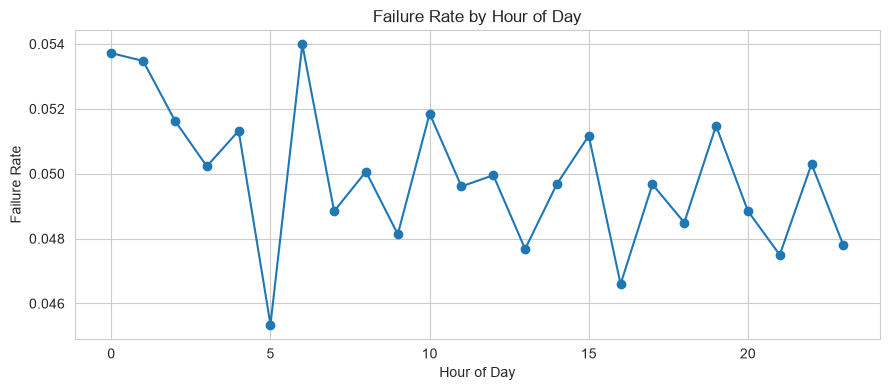

In [16]:
# Time vs Failure Rate
failure_by_hour = df.groupby('hour_of_day').apply(
    lambda g: (g['transaction_status'] == 'FAILED').mean()
)
failure_by_hour.plot(kind='line', marker='o', figsize=(9, 4), title='Failure Rate by Hour of Day')
plt.ylabel('Failure Rate')
plt.xlabel('Hour of Day')
plt.tight_layout()
plt.show()

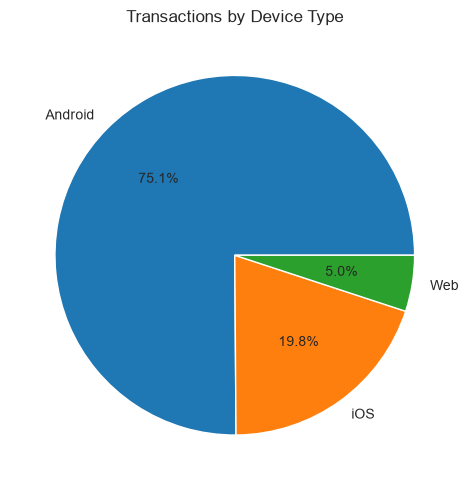

In [17]:
# Device Type vs Usage
device_share = df['device_type'].value_counts(normalize=True) * 100
device_share.plot(kind='pie', autopct='%1.1f%%', figsize=(5, 5), title='Transactions by Device Type')
plt.ylabel('')
plt.tight_layout()
plt.show()

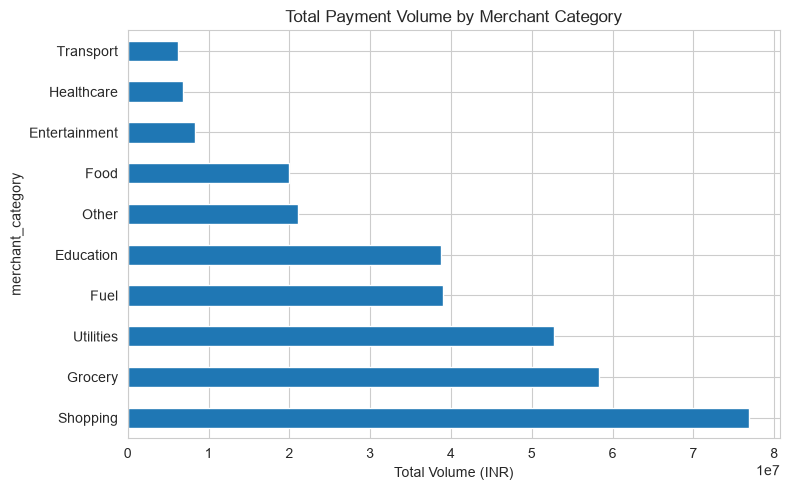

In [18]:
# Merchant Category vs Revenue
revenue_by_category = df.groupby('merchant_category')['amount (INR)'].sum().sort_values(ascending=False)
revenue_by_category.plot(kind='barh', figsize=(8, 5), title='Total Payment Volume by Merchant Category')
plt.xlabel('Total Volume (INR)')
plt.tight_layout()
plt.show()

## 6. Customer Segmentation
Since this dataset is transaction-level (no unique customer ID), transactions are segmented directly by value — matching the `Segment` calculated column built in Power BI.

Segment
Low-Engagement User    42.6496
Regular User           37.6884
Frequent Transactor    15.2796
High-Value User         4.3824
Name: proportion, dtype: float64


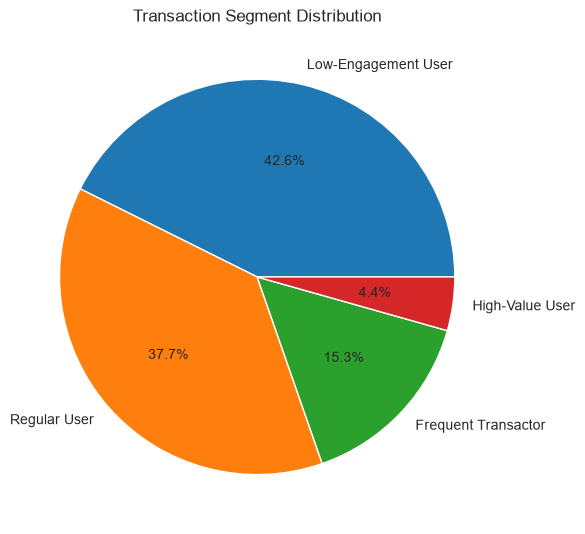

In [19]:
def segment(amount):
    if amount > 5000:
        return 'High-Value User'
    elif amount > 2000:
        return 'Frequent Transactor'
    elif amount > 500:
        return 'Regular User'
    else:
        return 'Low-Engagement User'

df['Segment'] = df['amount (INR)'].apply(segment)

segment_dist = df['Segment'].value_counts(normalize=True) * 100
print(segment_dist)

segment_dist.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Transaction Segment Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 7. Export Cleaned Data (optional)
Uncomment to save the cleaned dataset for reuse.

In [20]:
# df.to_csv('../data/upi_transactions_2024_cleaned.csv', index=False)